# PS8 – Firm Investment, Costly External Finance, and SMM

This exercise is based on **Cooper & Ejarque (2003)** and studies how financial frictions affect firms’ investment behavior.  
The key idea is that firms face:

- A **dynamic** decision problem for capital accumulation,
- A **quadratic adjustment cost** of changing the capital stock,
- And **costly external finance**: raising funds from outside investors is not free (fixed + possibly linear cost).

Because of these frictions, investment depends not only on standard “Tobin’s Q” style incentives, but also on **internal funds (profits/cash flow)** and the option to tap external capital markets.

---

### The goal of this notebook:

The goal is to **take the model to the data** and see whether a firm-level investment model with costly external finance can replicate a set of empirical moments (mainly from an investment–Q regression), and then **estimate the structural parameters** via **Simulated Method of Moments (SMM)**.



In [1]:
# Importing the required libraries
import numpy as np
import pandas as pd
from dataclasses import dataclass
import matplotlib.pyplot as plt
from typing import Dict, Any, Tuple
from scipy.optimize import minimize

## Discretizing the Productivity Process: Tauchen (1986)

The firm’s idiosyncratic productivity follows a continuous AR(1) in logs:

$$
a_{t+1} = \rho a_t + \sigma \varepsilon_{t+1}, \quad \varepsilon_{t+1} \sim \mathcal{N}(0,1),
$$
$$
A_t = e^{a_t}.
$$

To solve the dynamic programming problem on a computer, I cannot work with the continuous distribution directly.  
Instead, I **approximate the AR(1)** with a *finite-state Markov chain* using the **Tauchen (1986)** method:

- Choose a grid of `nA` points for the log state $a$:
  - The grid covers roughly $[ \mu - m \cdot \sigma_a,\ \mu + m \cdot \sigma_a ]$, where
    $\sigma_a^2 = \sigma^2/(1-\rho^2)$ is the unconditional variance of the AR(1).
- For each grid point $a_j$, compute transition probabilities to all other grid points \(a_k\)
  based on the normal distribution of $a_{t+1}$ given $a_t = a_j$.
- Exponentiate the grid to obtain the productivity grid $A = e^a$.


The Tauchen function, therefore, returns:
1. `Agrid`: the discrete grid for productivity $A$,
2. `P`: the transition matrix for the Markov chain over the A-grid,
3. optionally the log-grid `agrid`.

This discrete Markov chain is what the DP solver uses as the law of motion for productivity.




In [2]:
# ------------------ Tauchen -----------------
def tauchen(n:int, rho:float, sigma:float, m:float=3.0, mu:float=0.0):
    """
    Tauchen (1986) discretization for AR(1) in logs:
      a' = (1-rho)*mu + rho*a + sigma*eps, eps~N(0,1).
    Returns grid (levels A = exp(a)), transition matrix P, and the a-grid.
    """
    std = sigma/np.sqrt(1.0-rho**2)
    a_max = mu + m*std
    a_min = mu - m*std
    a_grid = np.linspace(a_min, a_max, n)
    step = (a_max - a_min)/(n-1)
    P = np.zeros((n,n))
    for i in range(n):
        mean_next = (1 - rho)*mu + rho*a_grid[i]
        for j in range(n):
            if j == 0:
                z_low = -np.inf
            else:
                z_low = (a_grid[j] - step/2 - mean_next)/sigma
            if j == n-1:
                z_high = np.inf
            else:
                z_high = (a_grid[j] + step/2 - mean_next)/sigma
            P[i,j] = 0.5*(1+erf(z_high/np.sqrt(2))) - 0.5*(1+erf(z_low/np.sqrt(2)))

    # Numerical cleanup: ensure rows are non-negative and sum to one
    P = np.maximum(P, 0.0)
    row_sums = P.sum(axis=1, keepdims=True)
    # if any row sums are (near) zero (shouldn't happen), replace by uniform
    near_zero = (row_sums.flatten() < 1e-14)
    if np.any(near_zero):
        P[near_zero, :] = 1.0 / n
        row_sums = P.sum(axis=1, keepdims=True)
    P = P / row_sums

    return np.exp(a_grid), P, a_grid


def erf(x):
    # Abramowitz & Stegun approximation
    sign = np.sign(x)
    x = np.abs(x)
    t = 1.0/(1.0 + 0.3275911*x)
    a1,a2,a3,a4,a5 = 0.254829592,-0.284496736,1.421413741,-1.453152027,1.061405429
    y = 1.0 - (((((a5*t + a4)*t) + a3)*t + a2)*t + a1)*t*np.exp(-x*x)
    return sign*y
           

## Dynamic Programming Problem of the Firm (Cooper & Ejarque, 2003)

### Economic environment

Each firm has:

- **State variables**:
  - Capital stock $K_t$,
  - Idiosyncratic productivity $A_t$ (discretized using Tauchen as described above).

- **Choice variable**:
  - Investment rate $i_t$, which determines next period's capital:
    $$
    K_{t+1} = (1 - \delta) K_t + i_t K_t.
    $$

- **Profits** (before investment and adjustment costs):
  $$
  \pi_t = A_t K_t^\alpha.
  $$

- **Quadratic adjustment cost** of investment:
  $$
  \text{AC}_t = \frac{\gamma}{2} i_t^2 K_t.
  $$

- **Dividends (or internal funds)** before external finance:
  $$
  d_t = \pi_t - I_t - \text{AC}_t
      = \pi_t - i_t K_t - \frac{\gamma}{2} i_t^2 K_t.
  $$

If $d_t \ge 0$, the firm can finance investment entirely with internal funds (the **internal regime**).  
If $d_t < 0$, the firm needs **external funds**:

$$
E_t = \max\{ I_t + \text{AC}_t - \pi_t,\ 0 \}.
$$

External funds are **costly**:

- A *fixed cost* $\phi_0$ if the firm taps external finance at all,
- plus (optionally) a linear cost $\phi_1 E_t$.

### Value functions and regimes

Let:

- $V^i(A,K)$ be the value if the firm uses only **internal** finance in the current period,
- $V^e(A,K)$ be the value if the firm uses **external** finance and pays the fixed + linear cost.

Then the full value function is:
$$
V(A,K) = \max \{ V^i(A,K),\ V^e(A,K) \}.
$$

In the discrete implementation:

- I have grids for $A$ and $K$,
- and an investment-rate grid for $i$,
- for each $(A,K)$, the code loops over all possible $i$ and:
  - computes $K'$,
  - computes $I$, adjustment costs, dividends, and required external funds,
  - checks feasibility for the **internal** branch (require $d_t \ge 0$),
  - checks feasibility for the **external** branch (require $E_t > 0$),
  - adds the discounted expected continuation value $ \beta \mathbb{E}[V(A',K')] $,
  - picks the $i$ and regime (internal vs external) that give the highest value.

### Numerical solution: value function iteration

The `DPSolver` class implements **value function iteration**:

1. **Initialize** $V_0(A,K)$ to some guess (here zero for all states).
2. **Given** $V$, compute the **expected continuation value**:
   $$
   \mathbb{E}[V(A',K')] = \sum_{A'} P(A' \mid A) V(A',K'),
   $$
   using the transition matrix from Tauchen.
3. For each current state $(A,K)$, and each investment choice $i$:
   - Compute the implied $K'$,
   - Check whether $K'$ is within the capital grid (if not, treat this choice as infeasible),
   - Compute the internal and external regime values:
     $$
     \text{val}^{int} = d_t + \beta \mathbb{E}[V(A',K')],
     \quad
     \text{val}^{ext} = (\pi_t - I_t - \text{AC}_t - \phi_0 - \phi_1 E_t) + \beta \mathbb{E}[V(A',K')].
     $$
   - Take the maximum across internal/external regimes and across all $i$.
4. Update the value function:
   $$
   V_{new}(A,K) = \max_{i,\ \text{regime}} \{ \text{val}^{int}, \text{val}^{ext} \},
   $$
   and repeat until $\|V_{new} - V\|_{\infty} < \text{tol}$.

The outcome of this DP step is:

- A 2D array `V[a_idx, k_idx]` with the value function,
- A policy function for the **investment rate** `i` at each $(A,K)$,
- An indicator for whether the **external regime** is used (0 = internal, 1 = external).

These policy functions are then used in the **simulation step** to generate panel data and implement SMM.


In [3]:
@dataclass
class Params:
    alpha: float = 0.6956   # profit curvature
    beta: float = 0.95    # discount
    delta: float = 0.15   # depreciation
    gamma: float = 0.1331   # adj cost coefficient for quadratic in i
    rho: float = 0.0976     # AR(1) persistence in log A
    sigma: float = 0.8932    # AR(1) std in log A
    phi0: float = 0.0     # fixed cost of external finance (level, not normalized)
    phi1: float = 0.0    # marginal linear cost on external funds
    # grids
    nk:int=55
    nA:int=7
    ni:int=61
    kmin:float=1.0
    kmax:float=100.0
    i_low:float=-0.30
    i_high:float=0.60
    

def adjust_cost(i, k, gamma):
    # Quadratic adj cost in i per-CE (γ/2)*i^2 * K
    return 0.5*gamma*(i**2)*k

class DPSolver:
    """
    DP for Cooper & Ejarque (2003) with costly external finance (Section 3).
    Two regimes: internal (dividends >= 0) and external (pay fixed+linear cost if E = I - pi > 0).
    Restrict K' to the K-grid.
    """
    def __init__(self, p:Params):
        self.p = p
        # choose mu so that E[A]=1 => mu = -0.5*Var(log A)
        var_a = (p.sigma**2)/max(1e-12, (1 - p.rho**2))
        mu = -0.5*var_a
        Agrid, P, _ = tauchen(p.nA, p.rho, p.sigma, 3.0, mu)
        self.Agrid, self.PA = Agrid, P
        self.Kgrid = np.linspace(p.kmin, p.kmax, p.nk)
        self.igrid = np.linspace(p.i_low, p.i_high, p.ni)

    def solve(self, max_iter=500, tol=1e-6, verbose=False) -> Dict[str,Any]:
        p = self.p
        K = self.Kgrid; A = self.Agrid; P = self.PA
        nk, nA = len(K), len(A)
        V = np.zeros((nA, nk))
        pol_i_idx = np.zeros((nA, nk), dtype=int)
        pol_ext = np.zeros((nA, nk), dtype=np.int8)  # 1 if choose external regime

        one_md = (1.0 - p.delta)

        for it in range(max_iter):
            Vnew = np.empty_like(V)
            pi_idx_new = np.empty_like(pol_i_idx)
            ext_new = np.empty_like(pol_ext)

            EV = P @ V  # nA x nk (expected value conditional on current A, for each K')
            # We’ll evaluate over discrete i -> K' = one_md*K + i*K
            for ia in range(nA):
                a = A[ia]
                # profits and K arrays for vectorization
                prof = a*(K**p.alpha)                  # shape (nk,)
                Kc = K.reshape(nk,1)                   # nk x 1
                i = self.igrid.reshape(1, p.ni)        # 1 x ni
                Kp = one_md*Kc + i*Kc                  # nk x ni
                # mask feasible K' into grid bounds (clip), but keep i consistent with clipped K'
                Kp_clipped = np.clip(Kp, K[0], K[-1])

                # Round K' to nearest grid point (discrete choice). Find nearest indices.
                kp_idx = np.searchsorted(K, Kp_clipped)  # nk x ni, index of insertion
                kp_idx = np.clip(kp_idx, 1, nk-1)
                left = K[kp_idx-1]; right = K[kp_idx]
                choose_right = (np.abs(Kp_clipped - right) < np.abs(Kp_clipped - left))
                kp_idx = np.where(choose_right, kp_idx, kp_idx-1)  # nearest index

                # Recompute implied i from discrete K' to ensure consistency
                Kp_disc = K[kp_idx]
                i_disc = (Kp_disc - one_md*Kc)/Kc

                # objects
                AC = 0.5*p.gamma*(i_disc**2)*Kc           # nk x ni
                I = i_disc*Kc                              # nk x ni
                cash = prof.reshape(nk,1) - I - AC         # dividends before finance
                E_need = I + AC - prof.reshape(nk,1)     # external funds needed if positive

                E_need = I - prof.reshape(nk,1)            

                # Regime values
                # INTERNAL: require cash >= 0
                internal_ok = cash >= -1e-12
                rew_int = np.where(internal_ok, cash, -1e20)

                # EXTERNAL: allowed only if E_need > 0
                ext_ok = E_need > 1e-12
                # reward_e = profits - I - AC - phi0 - phi1 * E
                rew_ext = np.where(ext_ok, prof.reshape(nk,1) - I - AC - p.phi0 - p.phi1*E_need, -1e20)

                # Continuation values from EV (pick at discrete kp_idx)
                EV_row = EV[ia, :]  # length nk over K'
                EV_disc = EV_row[kp_idx]  # nk x ni

                val_int = rew_int + p.beta*EV_disc
                val_ext = rew_ext + p.beta*EV_disc
                # pick best across regimes per i
                val_best_i = np.maximum(val_int, val_ext)
                # pick best i
                best_i_idx = np.argmax(val_best_i, axis=1)  # length nk
                Vnew[ia,:] = val_best_i[np.arange(nk), best_i_idx]
                pi_idx_new[ia,:] = best_i_idx
                # ext chosen?
                ext_flag = (val_ext[np.arange(nk), best_i_idx] > val_int[np.arange(nk), best_i_idx]).astype(np.int8)
                ext_new[ia,:] = ext_flag

            diff = np.max(np.abs(Vnew - V))
            V = Vnew; pol_i_idx = pi_idx_new; pol_ext = ext_new
            if verbose and (it % 20 == 0 or diff < tol):
                print(f"Iter {it:3d}: |ΔV|∞ = {diff:.3e}")
            if diff < tol:
                break

        out = {
            "V": V, "pol_i_idx": pol_i_idx, "pol_ext": pol_ext,
            "Kgrid": K, "Agrid": A, "PA": P,
            "igrid": self.igrid
        }
        return out

    def policy_to_kprime(self, dp:Dict[str,Any]) -> np.ndarray:
        p = self.p
        K = self.Kgrid; nk = len(K)
        i_idx = dp["pol_i_idx"]  # nA x nk -> index into igrid
        i = self.igrid[i_idx]    # nA x nk
        Kp = (1.0 - p.delta)*K.reshape(1,nk) + i*K.reshape(1,nk)
        # snap Kp back to nearest grid point (consistent with solve)
        idx = np.searchsorted(K, Kp)
        idx = np.clip(idx, 1, nk-1)
        left = K[idx-1]; right = K[idx]
        choose_right = (np.abs(Kp - right) < np.abs(Kp - left))
        idx = np.where(choose_right, idx, idx-1)
        return K[idx]

# Instantiate parameters
p = Params()  # Uses defaults or pass custom values

# Solve the DP
solver = DPSolver(p)
dp = solver.solve(max_iter=500, tol=1e-6, verbose=True)

Iter   0: |ΔV|∞ = 2.732e+02
Iter  20: |ΔV|∞ = 2.191e+00
Iter  40: |ΔV|∞ = 7.856e-01
Iter  60: |ΔV|∞ = 2.816e-01
Iter  80: |ΔV|∞ = 1.010e-01
Iter 100: |ΔV|∞ = 3.619e-02
Iter 120: |ΔV|∞ = 1.297e-02
Iter 140: |ΔV|∞ = 4.651e-03
Iter 160: |ΔV|∞ = 1.667e-03
Iter 180: |ΔV|∞ = 5.977e-04
Iter 200: |ΔV|∞ = 2.143e-04
Iter 220: |ΔV|∞ = 7.682e-05
Iter 240: |ΔV|∞ = 2.754e-05
Iter 260: |ΔV|∞ = 9.872e-06
Iter 280: |ΔV|∞ = 3.539e-06
Iter 300: |ΔV|∞ = 1.269e-06
Iter 305: |ΔV|∞ = 9.817e-07


Plotting graphs for Capital, Investment rate and whether external finance used

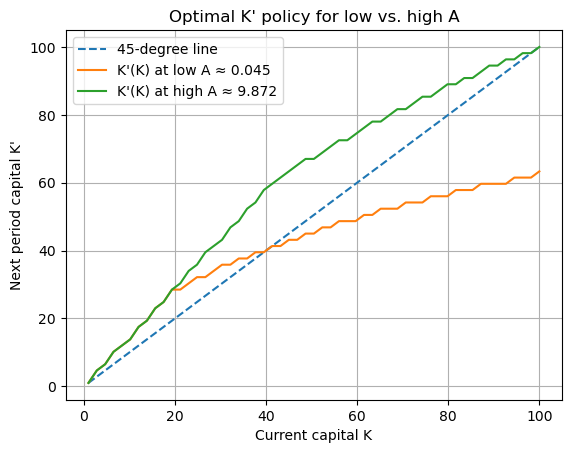

In [4]:
# Recover grids and policies from dp
K = dp["Kgrid"]      # capital grid, shape (nk,)
A = dp["Agrid"]      # productivity grid, shape (nA,)
ext = dp["pol_ext"]  # 0/1 external-finance indicator, shape (nA, nk)

# Getting K' policy as nA x nk array
Kp = solver.policy_to_kprime(dp)  # shape (nA, nk)

# Indices for "low A" and "high A"
ia_low  = 0           # smallest A
ia_high = len(A) - 1  # largest A

# ---- Plot K' as function of K for low and high A ----
plt.figure()
plt.plot(K, K, linestyle='--', label="45-degree line")  # K' = K
plt.plot(K, Kp[ia_low, :], label=f"K'(K) at low A ≈ {A[ia_low]:.3f}")
plt.plot(K, Kp[ia_high, :], label=f"K'(K) at high A ≈ {A[ia_high]:.3f}")
plt.xlabel("Current capital K")
plt.ylabel("Next period capital K'")
plt.title("Optimal K' policy for low vs. high A")
plt.legend()
plt.grid(True)
plt.savefig("Kprime_policy.png", dpi=300, bbox_inches="tight")
plt.show()


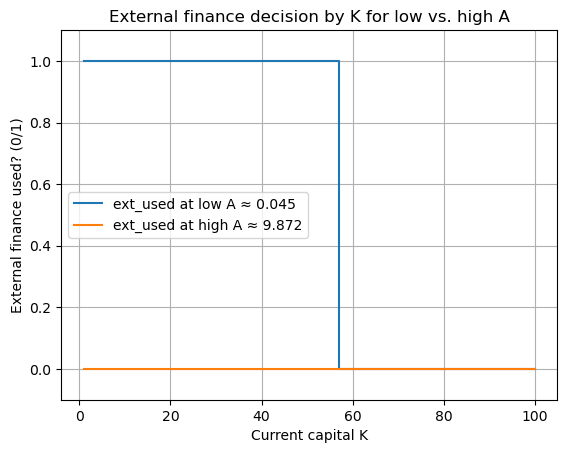

In [5]:
# ---- Plot external-finance region as function of K for low vs. high A ----
plt.figure()

plt.step(K, ext[ia_low, :], where='mid',
         label=f"ext_used at low A ≈ {A[ia_low]:.3f}")
plt.step(K, ext[ia_high, :], where='mid',
         label=f"ext_used at high A ≈ {A[ia_high]:.3f}")

plt.ylim(-0.1, 1.1)
plt.xlabel("Current capital K")
plt.ylabel("External finance used? (0/1)")
plt.title("External finance decision by K for low vs. high A")
plt.legend()
plt.grid(True)
plt.savefig("ext_finance_policy.png", dpi=300, bbox_inches="tight")
plt.show()


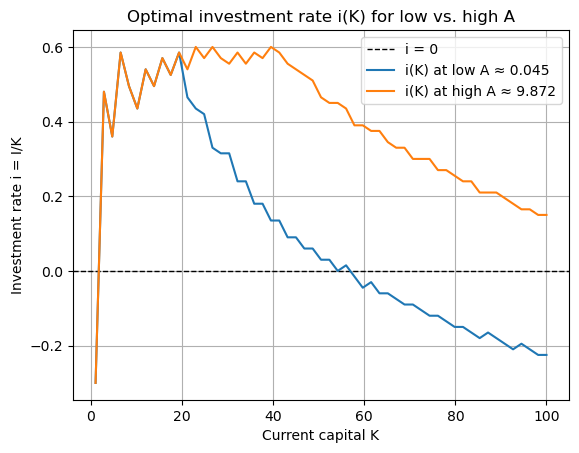

In [6]:
# ---- Plot i(K) for low vs high A ----

K     = dp["Kgrid"]        # capital grid, shape (nk,)
A     = dp["Agrid"]        # productivity grid, shape (nA,)
i_idx = dp["pol_i_idx"]    # optimal i index, shape (nA, nk)
igrid = dp["igrid"]        # investment-rate grid, shape (ni,)

# Convert policy indices into actual investment rates i(A,K)
i_policy = igrid[i_idx]    # shape (nA, nk)

plt.figure()
plt.axhline(0.0, color="k", linestyle="--", linewidth=1, label="i = 0")

plt.plot(K, i_policy[ia_low, :],
         label=f"i(K) at low A ≈ {A[ia_low]:.3f}")
plt.plot(K, i_policy[ia_high, :],
         label=f"i(K) at high A ≈ {A[ia_high]:.3f}")

plt.xlabel("Current capital K")
plt.ylabel("Investment rate i = I/K")
plt.title("Optimal investment rate i(K) for low vs. high A")
plt.legend()
plt.grid(True)
plt.savefig("investment_rate_policy.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 2: Simulating the panel of firms using the policy functions obtained by solving DP problem above

In [7]:
def simulate_panel(dpout: dict, p, N: int = 1000, T: int = 50, burn: int = 10, seed: int = 123) -> pd.DataFrame:
    """
    Simulate a panel of N firms for T periods (discard first `burn`),
    given a solved DP from DPSolver class.

    Parameters
    ----------
    dpout : dict
        Output from DPSolver.solve(...), containing:
        - "V"         : value function (nA x nK)
        - "pol_i_idx" : policy indices into the investment-rate grid (nA x nK)
        - "pol_ext"   : 0/1 external finance indicator (nA x nK)
        - "Agrid"     : productivity grid (nA,)
        - "PA"        : transition matrix for A (nA x nA)
        - "Kgrid"     : capital grid (nK,)
        - "igrid"     : investment-rate grid (ni,)
    p : Params
        Parameter object used to solve the DP (must have alpha,beta,delta,gamma).
    N, T, burn, seed : int
        Number of firms, total periods, burn-in to drop, RNG seed.

    Returns
    -------
    panel : pandas.DataFrame
        Columns: firm, t, A, K, i, I, Kp, profit, adjcost, cash, ext_used, E,
                 qbar, qbar_next_exp, inv_rate, profit_rate
    """
    rng   = np.random.default_rng(seed)
    V     = dpout["V"]
    pol_i = dpout["pol_i_idx"]
    polex = dpout["pol_ext"]
    Agrid = dpout["Agrid"]
    PA    = dpout["PA"]
    Kgrid = dpout["Kgrid"]
    igrid = dpout["igrid"]

    nA, nK = V.shape
    one_md = 1.0 - p.delta

    # Stationary distribution of A (left eigenvector via power iteration)
    pi = np.ones(nA)/nA
    for _ in range(2000):
        pi_new = pi @ PA
        if np.max(np.abs(pi_new - pi)) < 1e-14:
            break
        pi = pi_new

    # Initialize states
    A_idx = rng.choice(nA, size=N, p=pi)
    K_idx = np.full(N, nK//2, dtype=int)  # start at mid grid
    PA_cum = np.cumsum(PA, axis=1)

    rows = []
    for t in range(T):
        # Policy lookups
        i_idx   = pol_i[A_idx, K_idx]                # (N,)
        extflag = polex[A_idx, K_idx].astype(int)    # (N,)

        # Current states and controls
        K = Kgrid[K_idx]                              # (N,)
        i = igrid[i_idx]                              # (N,)
        I = i*K
        A = Agrid[A_idx]
        prof = A*(K**p.alpha)
        AC   = 0.5*p.gamma*(i**2)*K
        cash = prof - I - AC
        E_need = np.clip(I - prof, 0.0, None)

        # Realized average-Q proxy
        qbar = np.where(K>0, V[A_idx, K_idx]/K, np.nan)

        # Next K: (1-δ)K + I, snapped to nearest grid (consistent with DP)
        Kp_cont = one_md*K + I
        idx = np.searchsorted(Kgrid, Kp_cont)
        idx = np.clip(idx, 1, nK-1)
        left = Kgrid[idx-1]; right = Kgrid[idx]
        choose_right = (np.abs(Kp_cont - right) < np.abs(Kp_cont - left))
        Kp_idx = np.where(choose_right, idx, idx-1)
        Kp = Kgrid[Kp_idx]

        # Expected next Qbar given current A and chosen K'
        # row-wise dot: sum_j P(A->A'_j) * V(A'_j, K')
        EV_next = np.sum(PA[A_idx,:] * (V[:, Kp_idx].T), axis=1)
        qbar_next_exp = np.where(Kp>0, EV_next / Kp, np.nan)

        if t >= burn:
            rows.append(pd.DataFrame({
                "firm": np.arange(N, dtype=int),
                "t": t-burn,
                "A": A, "K": K, "i": i, "I": I, "Kp": Kp,
                "profit": prof, "adjcost": AC, "cash": cash,
                "ext_used": extflag, "E": E_need,
                "qbar": qbar, "qbar_next_exp": qbar_next_exp
            }))

        # Advance A with the Markov chain
        u = rng.random(size=N)
        A_next = np.empty_like(A_idx)
        for n in range(N):
            A_next[n] = np.searchsorted(PA_cum[A_idx[n]], u[n])
        A_idx = A_next
        K_idx = Kp_idx

    panel = pd.concat(rows, ignore_index=True)
    panel["inv_rate"]    = panel["I"] / panel["K"]
    panel["profit_rate"] = panel["profit"] / panel["K"]
    panel.replace([np.inf, -np.inf], np.nan, inplace=True)
    panel.dropna(inplace=True)
    return panel


# Simulate a panel
panel = simulate_panel(dp, p, N=1000, T=50, burn=10, seed=123)

# Save the panel to CSV 
panel.to_csv("firm_panel_simulated.csv", index=False)
print(panel.head())
print("Firms:", panel["firm"].nunique(), "  Periods:", panel["t"].nunique(), "  Rows:", len(panel))


   firm  t         A          K     i       I         Kp      profit  \
0     0  0  1.640080  57.833333  0.24  13.880  63.333333   27.582672   
1     1  0  0.668486  61.500000  0.15   9.225  61.500000   11.733673   
2     2  0  0.668486  68.833333  0.09   6.195  65.166667   12.690107   
3     3  0  1.640080  59.666667  0.24  14.320  65.166667   28.187995   
4     4  0  9.872124  59.666667  0.39  23.270  74.333333  169.671779   

    adjcost        cash  ext_used    E      qbar  qbar_next_exp  inv_rate  \
0  0.221691   13.480981         0  0.0  3.185276       2.842748      0.24   
1  0.092089    2.416584         0  0.0  2.761876       2.865876      0.15   
2  0.037105    6.458002         0  0.0  2.573622       2.764767      0.09   
3  0.228719   13.639276         0  0.0  3.124615       2.793328      0.24   
4  0.603961  145.797818         0  0.0  5.565431       2.642970      0.39   

   profit_rate  
0     0.476934  
1     0.190791  
2     0.184360  
3     0.472424  
4     2.843661  
Fi

## Step 3: Compute model-implied moments

   From the simulated panel, I construct the same moments as in the data using a function `compute_moments(panel)`:

   - Coefficients $a_1$ and $a_2$ from an investment regression:
     $$
     \frac{I_t}{K_t} = a_0 + a_1\, \mathbb{E}_t[\bar{q}_{t+1}] + a_2 \left(\frac{\pi_t}{K_t}\right) + u_t,
     $$
     where $\bar{q}_{t+1}$ is the model-implied Q.
   - Serial correlation of $I_t/K_t$.
   - Standard deviation of the profit rate $\pi_t/K_t$.
   - Mean of $\bar{q}$.
   - The fraction of investment financed externally.


In [16]:
def compute_moments(panel):
    df = panel.copy()
    df["inv_rate"]    = df["I"] / df["K"]
    df["profit_rate"] = df["profit"] / df["K"]

    # regression: inv_rate ~ const + qbar_next_exp + profit_rate
    X = np.column_stack([
        np.ones(len(df)),
        df["qbar_next_exp"].to_numpy(),   # you can add this to simulate_panel later
        df["profit_rate"].to_numpy()
    ])
    y = df["inv_rate"].to_numpy()
    beta = np.linalg.pinv(X.T @ X) @ (X.T @ y)
    a1 = beta[1]
    a2 = beta[2]

    # serial corr of inv_rate by firm, then average
    def firm_serial(g):
        s = g["inv_rate"].to_numpy()
        if len(s) < 2: return np.nan
        return np.corrcoef(s[:-1], s[1:])[0,1]
    ser = df.groupby("firm").apply(firm_serial).dropna().mean()

    std_profit = df["profit_rate"].std(ddof=1)
    mean_qbar  = df["qbar"].mean()

    total_I = df["I"].sum()
    total_E = df["E"].sum()
    ext_share = total_E / total_I if total_I != 0 else np.nan

    return np.array([a1, a2, ser, std_profit, mean_qbar, ext_share])


# 1) Simulate panel
panel = simulate_panel(dp, p, N=1000, T=50, burn=10, seed=123)

# 2) Compute simulated moments
m_sim = compute_moments(panel)

# 3) Print them
labels = ["a1_q", "a2_profit", "serial_inv", "std_profit_rate", "mean_qbar", "ext_invest_frac"]
for name, val in zip(labels, m_sim):
    print(f"{name:17s} = {val: .4f}")


a1_q              =  0.0739
a2_profit         =  0.1977
serial_inv        = -0.1592
std_profit_rate   =  0.3331
mean_qbar         =  2.8868
ext_invest_frac   =  0.0332


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()


## Step 4: I now compute the distance between model moments and simulated moments

In [17]:
m_sim = compute_moments(panel)
m_data = np.array([0.03, 0.24, 0.4, 0.25, 3.0, 0.25]) 
diff = m_sim - m_data
print("moment diff:", diff) 

moment diff: [ 0.04385834 -0.04230971 -0.5592337   0.08314223 -0.11319436 -0.21677498]


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()


## Step 5: SMM Estimation – Setup

In this section, I set up the SMM problem following Problem Set 8 and Cooper & Ejarque (2003):

- I match **6 moments** from the data:  
  $
  a_1, a_2, \text{sc}(I/K), \text{std}(\pi/K), \bar q, \text{Ext. frac.} 
  $.
- The model parameters to be **estimated** are:  
  $ \Theta = (\alpha, \gamma, \rho, \sigma, \phi_0) $.
- Some parameters are **calibrated** (fixed) as in the paper: $ \beta, \delta, \phi_1 $.

The SMM objective is:
$$
J(\Theta) = [m^{sim}(\Theta) - m^{data}]' W [m^{sim}(\Theta) - m^{data}],
$$
where $m^{sim}(\Theta)$ are the simulated moments and $W$ is a weighting matrix.




### Step 5.1: First-stage SMM with Identity Weighting

In the first SMM stage, I use the **identity matrix** as the weighting matrix: \(W = I\).

The objective function is:
$$
J_1(\Theta) = \big(m^{sim}(\Theta) - m^{data}\big)' \big(m^{sim}(\Theta) - m^{data}\big).
$$

I then use `scipy.optimize.minimize` with the L-BFGS-B algorithm to search over
$\Theta = (\alpha, \gamma, \rho, \sigma, \phi_0)$, subject to economically reasonable bounds,
while keeping $\beta, \delta, \phi_1$ fixed at the values suggested in the paper/PS8.


In [19]:
labels = ["a1_q","a2_profit","serial_inv","std_profit_rate","mean_qbar","ext_invest_frac"]
m_data = np.array([0.03, 0.24, 0.4, 0.25, 3.0, 0.25], dtype=float)     # <-- fill with Table 3 targets (PS8)
p_fix  = Params(                          # your calibrated values + grid choices
    alpha=0.6956, beta=0.95, delta=0.15, gamma=0.1331,
    rho=0.0976, sigma=0.8932, phi0=0.0, phi1=0.0,
    nk=55, nA=7, kmin=1.0, kmax=100.0, i_low=-0.30, i_high=0.60, ni=61
)

def smm_objective_stage1(theta):
    alpha, gamma, rho, sigma, phi0 = theta
    p = Params(alpha=alpha, beta=p_fix.beta, delta=p_fix.delta,
               gamma=gamma, rho=rho, sigma=sigma,
               phi0=phi0, phi1=p_fix.phi1,
               nk=p_fix.nk, nA=p_fix.nA, kmin=p_fix.kmin, kmax=p_fix.kmax,
               i_low=p_fix.i_low, i_high=p_fix.i_high, ni=p_fix.ni)

    dp = DPSolver(p).solve(max_iter=500, tol=1e-6, verbose=False)
    panel = simulate_panel(dp, p, N=1000, T=50, burn=10, seed=123)  # fixed seed for deterministic J
    m_sim = compute_moments(panel)
    diff  = m_sim - m_data
    return float(diff @ diff)

# Reasonable bounds (keeps optimizer in economic region)
bounds = [(0.10, 1.50),   # alpha
          (1e-4, 1.00),   # gamma
          (0.01, 0.99),   # rho
          (1e-3, 1.50),   # sigma
          (0.00, 0.50)]   # phi0  (level units in your code)

theta0 = np.array([0.6956, 0.1331, 0.0976, 0.8932, 0.0])
res1   = minimize(smm_objective_stage1, theta0, method="L-BFGS-B", bounds=bounds,
                  options={"maxiter": 150, "ftol": 1e-6, "disp": True})
theta_stage1 = res1.x
print("Stage‑1 θ =", theta_stage1)

C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()
C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()
C:\Users\Narender Narender\AppData\Local

Stage‑1 θ = [0.69613741 0.13305472 0.09764543 0.89322832 0.        ]


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()


In [20]:
# Print Stage‑1 results
print("\n=== Stage‑1 (Identity weighting) ===")
print("theta_stage1 (alpha, gamma, rho, sigma, phi0):")
print(theta_stage1)


def simulate_moments(theta, seed):
    alpha, gamma, rho, sigma, phi0 = theta
    p = Params(alpha=alpha, beta=p_fix.beta, delta=p_fix.delta,
               gamma=gamma, rho=rho, sigma=sigma,
               phi0=phi0, phi1=p_fix.phi1,
               nk=p_fix.nk, nA=p_fix.nA, kmin=p_fix.kmin, kmax=p_fix.kmax,
               i_low=p_fix.i_low, i_high=p_fix.i_high, ni=p_fix.ni)
    dp = DPSolver(p).solve(max_iter=500, tol=1e-6, verbose=False)
    panel = simulate_panel(dp, p, N=1000, T=50, burn=10, seed=seed)
    return compute_moments(panel)

# Evaluate and print the Stage‑1 moments and distance at theta_stage1
m1 = simulate_moments(theta_stage1, seed=123)
diff1 = m1 - m_data
J1 = float(diff1 @ diff1)
labels = ["a1_q","a2_profit","serial_inv","std_profit_rate","mean_qbar","ext_invest_frac"]

print("\nSimulated moments at theta_stage1:")
for name, val in zip(labels, m1):
    print(f"  {name:17s} = {val: .6f}")

print("\nTarget moments (data):")
for name, val in zip(labels, m_data):
    print(f"  {name:17s} = {val: .6f}")

print("\nMoment gaps (sim - data):")
for name, val in zip(labels, diff1):
    print(f"  {name:17s} = {val: .6f}")
print(f"\nStage‑1 distance J1 = {J1: .6f}")

# (Optional) save Stage‑1 estimates to CSV
import pandas as pd
pd.DataFrame({"param":["alpha","gamma","rho","sigma","phi0"],
              "theta_stage1": theta_stage1}).to_csv("theta_stage1.csv", index=False)



=== Stage‑1 (Identity weighting) ===
theta_stage1 (alpha, gamma, rho, sigma, phi0):
[0.69613741 0.13305472 0.09764543 0.89322832 0.        ]

Simulated moments at theta_stage1:
  a1_q              =  0.062588
  a2_profit         =  0.191188
  serial_inv        = -0.146128
  std_profit_rate   =  0.332740
  mean_qbar         =  2.878220
  ext_invest_frac   =  0.029851

Target moments (data):
  a1_q              =  0.030000
  a2_profit         =  0.240000
  serial_inv        =  0.400000
  std_profit_rate   =  0.250000
  mean_qbar         =  3.000000
  ext_invest_frac   =  0.250000

Moment gaps (sim - data):
  a1_q              =  0.032588
  a2_profit         = -0.048812
  serial_inv        = -0.546128
  std_profit_rate   =  0.082740
  mean_qbar         = -0.121780
  ext_invest_frac   = -0.220149

Stage‑1 distance J1 =  0.371843


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()


### Step 6.1: Estimating the Covariance Matrix of Moments, S

Following the two-step SMM approach in PS8, I now:

1. Fix the parameter vector at the **Stage-1 estimate** $ \hat{\Theta}_1 $.
2. Simulate **B independent panels** (with different random seeds).
3. For each panel, compute the 6 simulated moments.
4. Use the variability across simulations to estimate the **covariance matrix** of the moments, $S$.
5. Set the **efficient weighting matrix** to $W = S^{-1}$.

This captures how noisy each moment is and down-weights very volatile moments in the second-stage estimation.



### Step 6.2: Second-stage SMM with Efficient Weighting

Using the estimated covariance matrix $S$, I define the efficient weighting matrix
$$
W = S^{-1},
$$
and re-estimate the parameters by minimizing the **efficient** objective:
$$
J_2(\Theta) = [m^{sim}(\Theta) - m^{data}]' W [m^{sim}(\Theta) - m^{data}].
$$

This yields the final parameter vector $\hat{\Theta} $ that I will report in Table 3.


In [21]:


def estimate_S(theta_hat, B=190, base_seed=10_000):
    M = np.vstack([simulate_moments(theta_hat, base_seed + b) for b in range(B)])
    # covariance of the sample mean across panels = cov(M) / B_firms?  For two‑step SMM,
    # the usual practice is to use cov(M) of panel‑level moment vectors and invert it.
    S = np.cov(M, rowvar=False, ddof=1)
    # regularize a touch for numerical stability
    S += 1e-10*np.eye(S.shape[0])
    return S

S = estimate_S(theta_stage1, B=190)       #
W = np.linalg.pinv(S)

def smm_objective_stage2(theta):
    m_sim = simulate_moments(theta, seed=123)  # fixed seed again for deterministic objective
    diff  = m_sim - m_data
    return float(diff @ W @ diff)

res2 = minimize(smm_objective_stage2, theta_stage1, method="L-BFGS-B", bounds=bounds,
                options={"maxiter": 160, "ftol": 1e-6, "disp": True})
theta_hat = res2.x
print("Stage‑2 θ =", theta_hat)


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()
C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()
C:\Users\Narender Narender\AppData\Local

Stage‑2 θ = [0.69613741 0.13305472 0.09764543 0.89322832 0.        ]


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()


In [ ]:
print("\n=== Stage‑2 (Efficient SMM with W = S^{-1}) ===")
print("theta_hat (alpha, gamma, rho, sigma, phi0):")
print(theta_hat)

# Evaluate and print the Stage‑2 moments and distance at theta_hat
m2 = simulate_moments(theta_hat, seed=123)
diff2 = m2 - m_data
J2 = float(diff2 @ W @ diff2)

print("\nSimulated moments at theta_hat:")
for name, val in zip(labels, m2):
    print(f"  {name:17s} = {val: .6f}")

print("\nTarget moments (data):")
for name, val in zip(labels, m_data):
    print(f"  {name:17s} = {val: .6f}")

print("\nMoment gaps (sim - data):")
for name, val in zip(labels, diff2):
    print(f"  {name:17s} = {val: .6f}")
print(f"\nStage‑2 distance J2 = {J2: .6f}")




=== Stage‑2 (Efficient SMM with W = S^{-1}) ===
theta_hat (alpha, gamma, rho, sigma, phi0):
[0.69613741 0.13305472 0.09764543 0.89322832 0.        ]

Simulated moments at theta_hat:
  a1_q              =  0.062588
  a2_profit         =  0.191188
  serial_inv        = -0.146128
  std_profit_rate   =  0.332740
  mean_qbar         =  2.878220
  ext_invest_frac   =  0.029851

Target moments (data):
  a1_q              =  0.030000
  a2_profit         =  0.240000
  serial_inv        =  0.400000
  std_profit_rate   =  0.250000
  mean_qbar         =  3.000000
  ext_invest_frac   =  0.250000

Moment gaps (sim - data):
  a1_q              =  0.032588
  a2_profit         = -0.048812
  serial_inv        = -0.546128
  std_profit_rate   =  0.082740
  mean_qbar         = -0.121780
  ext_invest_frac   = -0.220149

Stage‑2 distance J2 =  145475.693214


C:\Users\Narender Narender\AppData\Local\Temp\ipykernel_36456\623996698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ser = df.groupby("firm").apply(firm_serial).dropna().mean()


## Step 6: Reporting Results – Table 3 (LaTeX)

The final step is to present the estimation results and moment matching in a table
similar to Table 3 in Cooper & Ejarque (2003).

I use the helper function `table3_latex` to generate a LaTeX table with:

- Panel (a): structural parameter estimates (and standard errors).
- Panel (b): the six moments from the data, the simulated moments, and the SMM objective value $J(\hat{\Theta})$.

This LaTeX output can be directly included in my write-up.


In [23]:
def table3_latex(theta_hat, se_theta=None, m_sim=None, m_data=None, J=None,
                 caption="Table 3", label="tab:table3",
                 model_name="Costly external finance"):
    """
    Build a LaTeX table matching Cooper & Ejarque (2003) Table 3 format.

    Inputs
    ------
    theta_hat : array-like, length 5 -> (alpha, gamma, rho, sigma, phi0)
    se_theta  : array-like or None   -> same order; printed in parentheses if provided
    m_sim     : array-like, length 6 -> (a1_q, a2_profit, serial_inv, std_profit_rate, mean_qbar, ext_invest_frac)
    m_data    : array-like or None   -> same order; shown in the 'Moments' row if provided
    J         : float or None        -> printed in the last column of panel (b)

    Returns
    -------
    str : LaTeX code for the whole table environment
    """

    def fmt(x):   # 4 decimals, robust to None
        return "" if x is None else f"{x:.4f}"
    def fmt_se(x):
        return "" if x is None else f"({x:.2f})"  # SEs commonly shown with 2 decimals

    # Panel (a): parameter estimates
    a, g, r, s, phi0 = [None if theta_hat is None else float(v) for v in theta_hat]
    if se_theta is not None:
        sa, sg, sr, ss, sphi = [float(v) for v in se_theta]
    else:
        sa, sg, sr, ss, sphi = [None]*5

    # Panel (b): moments
    if m_sim is not None:
        m1, m2, m3, m4, m5, m6 = [float(v) for v in m_sim]
    else:
        m1=m2=m3=m4=m5=m6=None

    if m_data is not None:
        d1, d2, d3, d4, d5, d6 = [float(v) for v in m_data]
    else:
        d1=d2=d3=d4=d5=d6=None

    Jstr = "" if J is None else f"{J:.2f}"

    # Build LaTeX
    tex = []
    tex += [r"\begin{table}[!ht]\centering"]
    tex += [rf"\caption{{{caption}}}"]
    tex += [rf"\label{{{label}}}"]

    # --- Panel (a) header ---
    tex += [r"\vspace{0.5em}"]
    tex += [r"\begin{tabular}{lccccc}"]
    tex += [r"\multicolumn{6}{c}{\textbf{(a) Structural parameter estimates: costly external finance } $(\Theta)$} \\ \hline"]
    tex += [r"Model & $\alpha$ & $\gamma$ & $\rho$ & $\sigma$ & $\tilde{\phi}_0$ \\ \hline"]

    # Estimates row (numbers)
    tex += [rf"{model_name} & {fmt(a)} & {fmt(g)} & {fmt(r)} & {fmt(s)} & {fmt(phi0)} \\"]

    # SEs row in parentheses
    if se_theta is not None:
        tex += [rf" & {fmt_se(sa)} & {fmt_se(sg)} & {fmt_se(sr)} & {fmt_se(ss)} & {fmt_se(sphi)} \\"]

    tex += [r"\hline"]
    tex += [r"\end{tabular}"]

    # --- Panel (b) header ---
    tex += [r"\vspace{0.8em}"]
    tex += [r"\begin{tabular}{lccccccc}"]
    tex += [r"\multicolumn{8}{c}{\textbf{(b) Moments by model}} \\ \hline"]
    tex += [r"Model & $a_1$ & $a_2$ & $\text{sc}(I/K)$ & $\text{std}(\pi/K)$ & $\bar{q}$ & \text{Ext. frac.} & $J(\Theta)$ \\ \hline"]

    # Data/targets row (if provided)
    if m_data is not None:
        tex += [rf"Moments & {fmt(d1)} & {fmt(d2)} & {fmt(d3)} & {fmt(d4)} & {fmt(d5)} & {fmt(d6)} & n.a. \\"]

    # Simulated/costly row
    tex += [rf"{model_name.split()[0]} & {fmt(m1)} & {fmt(m2)} & {fmt(m3)} & {fmt(m4)} & {fmt(m5)} & {fmt(m6)} & {Jstr} \\"]

    tex += [r"\hline"]
    tex += [r"\end{tabular}"]
    tex += [r"\end{table}"]

    return "\n".join(tex)


In [24]:

J2 = float((m2 - m_data) @ W @ (m2 - m_data))   # Stage-2 J(θ̂)

latex_table = table3_latex(
    theta_hat,
    se_theta= None,   # or se_theta=None if you don't have SEs
    m_sim=m2,
    m_data=m_data,
    J=J2,
    caption="Table 3: Structural estimates and moments",
    label="tab:ce03_table3",
    model_name="Costly"
)

print(latex_table)


\begin{table}[!ht]\centering
\caption{Table 3: Structural estimates and moments}
\label{tab:ce03_table3}
\vspace{0.5em}
\begin{tabular}{lccccc}
\multicolumn{6}{c}{\textbf{(a) Structural parameter estimates: costly external finance } $(\Theta)$} \\ \hline
Model & $\alpha$ & $\gamma$ & $\rho$ & $\sigma$ & $\tilde{\phi}_0$ \\ \hline
Costly & 0.6961 & 0.1331 & 0.0976 & 0.8932 & 0.0000 \\
\hline
\end{tabular}
\vspace{0.8em}
\begin{tabular}{lccccccc}
\multicolumn{8}{c}{\textbf{(b) Moments by model}} \\ \hline
Model & $a_1$ & $a_2$ & $\text{sc}(I/K)$ & $\text{std}(\pi/K)$ & $\bar{q}$ & \text{Ext. frac.} & $J(\Theta)$ \\ \hline
Moments & 0.0300 & 0.2400 & 0.4000 & 0.2500 & 3.0000 & 0.2500 & n.a. \\
Costly & 0.0626 & 0.1912 & -0.1461 & 0.3327 & 2.8782 & 0.0299 & 145475.69 \\
\hline
\end{tabular}
\end{table}
